In [39]:
from traceback import extract_stack

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from jupyter_client.jsonutil import squash_dates
from prompt_toolkit.data_structures import Size
from scipy.constants import year

DB = pd.read_csv("DS2.csv")
print(DB)


                    Name Color Rarity  # Seen  ALSA  # Picked    ATA   # GP  \
0          Another Round     W      R   64972  6.27      7953   9.59   1690   
1    Archangel of Tithes     W      M    9905  2.08      3697   2.15  18171   
2      Armored Armadillo     W      C  378941  7.89     40803  11.61  31423   
3       Aven Interrupter     W      R   24080  2.42      8609   2.64  44852   
4       Bounding Felidar     W      U   98493  4.11     18079   5.53  86683   
..                   ...   ...    ...     ...   ...       ...    ...    ...   
371     Contagion Engine   NaN      M    6499  2.44      2472   2.60  12573   
372           Grindstone   NaN      M   14203  4.84      1594   7.38   2175   
373           Mindslaver   NaN      M    9966  3.52      2026   4.30   7316   
374    Unlicensed Hearse   NaN      R   18252  3.05      4295   3.70  20486   
375            Dust Bowl   NaN      R   38100  6.57      4232  10.22   1271   

      % GP  GP WR   # OH  OH WR   # GD  GD WR  # GI

In [40]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

DB_Alter1 = DB.copy()
DB_Alter1 = DB_Alter1.drop(columns=["Name","Color","IWD"])
DB_Alter1 = DB_Alter1.dropna()
columnas_porcentaje = ['% GP', 'GP WR','OH WR','GD WR','GIH WR', 'GNS WR']

for col in columnas_porcentaje:
    # 1. Limpiar texto y convertir a float
    DB_Alter1[col] = (
        DB_Alter1[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
    )
    DB_Alter1[col] = pd.to_numeric(DB_Alter1[col], errors='coerce')

estandarizar = ["# Seen","# Picked", "# GP","% GP","GP WR","# OH", "OH WR", "# GD", "GD WR", "# GIH", "# GNS"]
normalizar = ["ALSA", "ATA", "GIH WR", "GNS WR"]
# Estandarizar
scaler_std = StandardScaler()
DB_Alter1[estandarizar] = scaler_std.fit_transform(DB_Alter1[estandarizar])

# Normalizar
scaler_min = MinMaxScaler(feature_range=(1,10))
DB_Alter1[normalizar] = scaler_min.fit_transform(DB_Alter1[normalizar])
print(DB_Alter1)

    Rarity    # Seen      ALSA  # Picked       ATA      # GP      % GP  \
1        M -0.971871  2.074438 -1.031444  1.772140 -0.807445  0.668843   
2        C  2.024898  9.418539  1.059833  9.626384 -0.645365 -2.119468   
3        R -0.856762  2.504213 -0.754606  2.178967 -0.481120  0.824636   
4        U -0.252489  4.640449 -0.220881  4.578413  0.030499  0.568975   
5        U  0.055929  7.446629 -0.534860  8.281365 -0.804986 -1.640102   
..     ...       ...       ...       ...       ...       ...       ...   
369      R -0.772041  6.801966 -0.974746  7.119004 -0.940391 -1.584176   
370      R -0.760233  7.294944 -0.989118  7.774908 -0.973634 -1.939706   
371      M -0.999529  2.529494 -1.100484  2.145756 -0.875912  0.816647   
373      M -0.971375  3.894663 -1.125620  3.557196 -0.940208 -0.126106   
374      R -0.904089  3.300562 -0.997741  3.059041 -0.779131  0.632890   

        GP WR      # OH     OH WR      # GD     GD WR     # GIH    GIH WR  \
1    0.237140 -0.805751  0.224059 

In [41]:
DB_Alter1[estandarizar] = DB_Alter1[estandarizar].round(2)
DB_Alter1[normalizar] = DB_Alter1[normalizar].round(2)


In [42]:
dic_DB_Rarity = {
    "C": 0,
    "U": 1,
    "R": 2,
    "M": 3
}
DB_Alter1["Rarity"] = DB_Alter1["Rarity"].map(dic_DB_Rarity)

In [43]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow as tf


y = DB_Alter1["Rarity"]
x = DB_Alter1.drop("Rarity", axis=1)

#y = DB_Alter["class"]
#x = DB_Alter.drop("class", axis=1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=21,stratify=y)

print("Características de entrada:", x_train.shape[1])
print("Class:", y.nunique())

model = Sequential()
model.add(Dense(32,input_dim=x_train.shape[1],activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(16,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(4,activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
history = model.fit(x_train,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=1)

result = model.evaluate(x_test,y_test,verbose=1)
print("Loss:", result[0])
print("Accuracy:", result[1])

Características de entrada: 15
Class: 4
Epoch 1/100


C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3281 - loss: 1.6351 - val_accuracy: 0.4898 - val_loss: 1.2004
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3646 - loss: 1.5342 - val_accuracy: 0.4898 - val_loss: 1.1309
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3750 - loss: 1.3998 - val_accuracy: 0.5918 - val_loss: 1.0946
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3125 - loss: 1.4353 - val_accuracy: 0.5918 - val_loss: 1.0728
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3646 - loss: 1.3073 - val_accuracy: 0.5714 - val_loss: 1.0524
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4219 - loss: 1.2062 - val_accuracy: 0.5510 - val_loss: 1.0360
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4271 - loss: 1.1453 - val_accuracy: 0.5306 - val_loss: 1.0186
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4531 - loss: 1.1734 - val_accuracy: 0.5714 - val_loss: 0.9965
Epoc

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


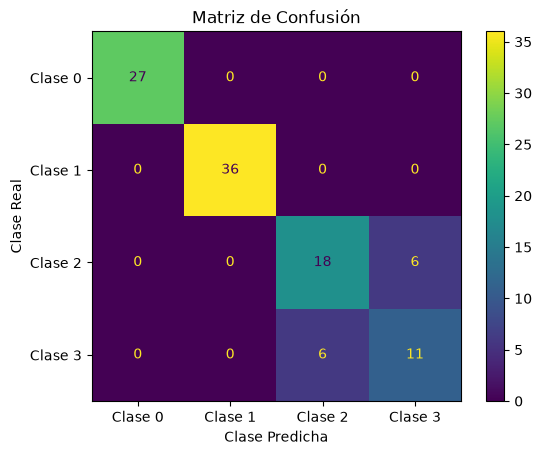

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones del modelo
y_pred = model.predict(x_test)

# Convertir probabilidades a la clase predicha
y_pred = y_pred.argmax(axis=1)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Clase 0", "Clase 1", "Clase 2","Clase 3"]
)

disp.plot()

plt.title("Matriz de Confusión")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.show()